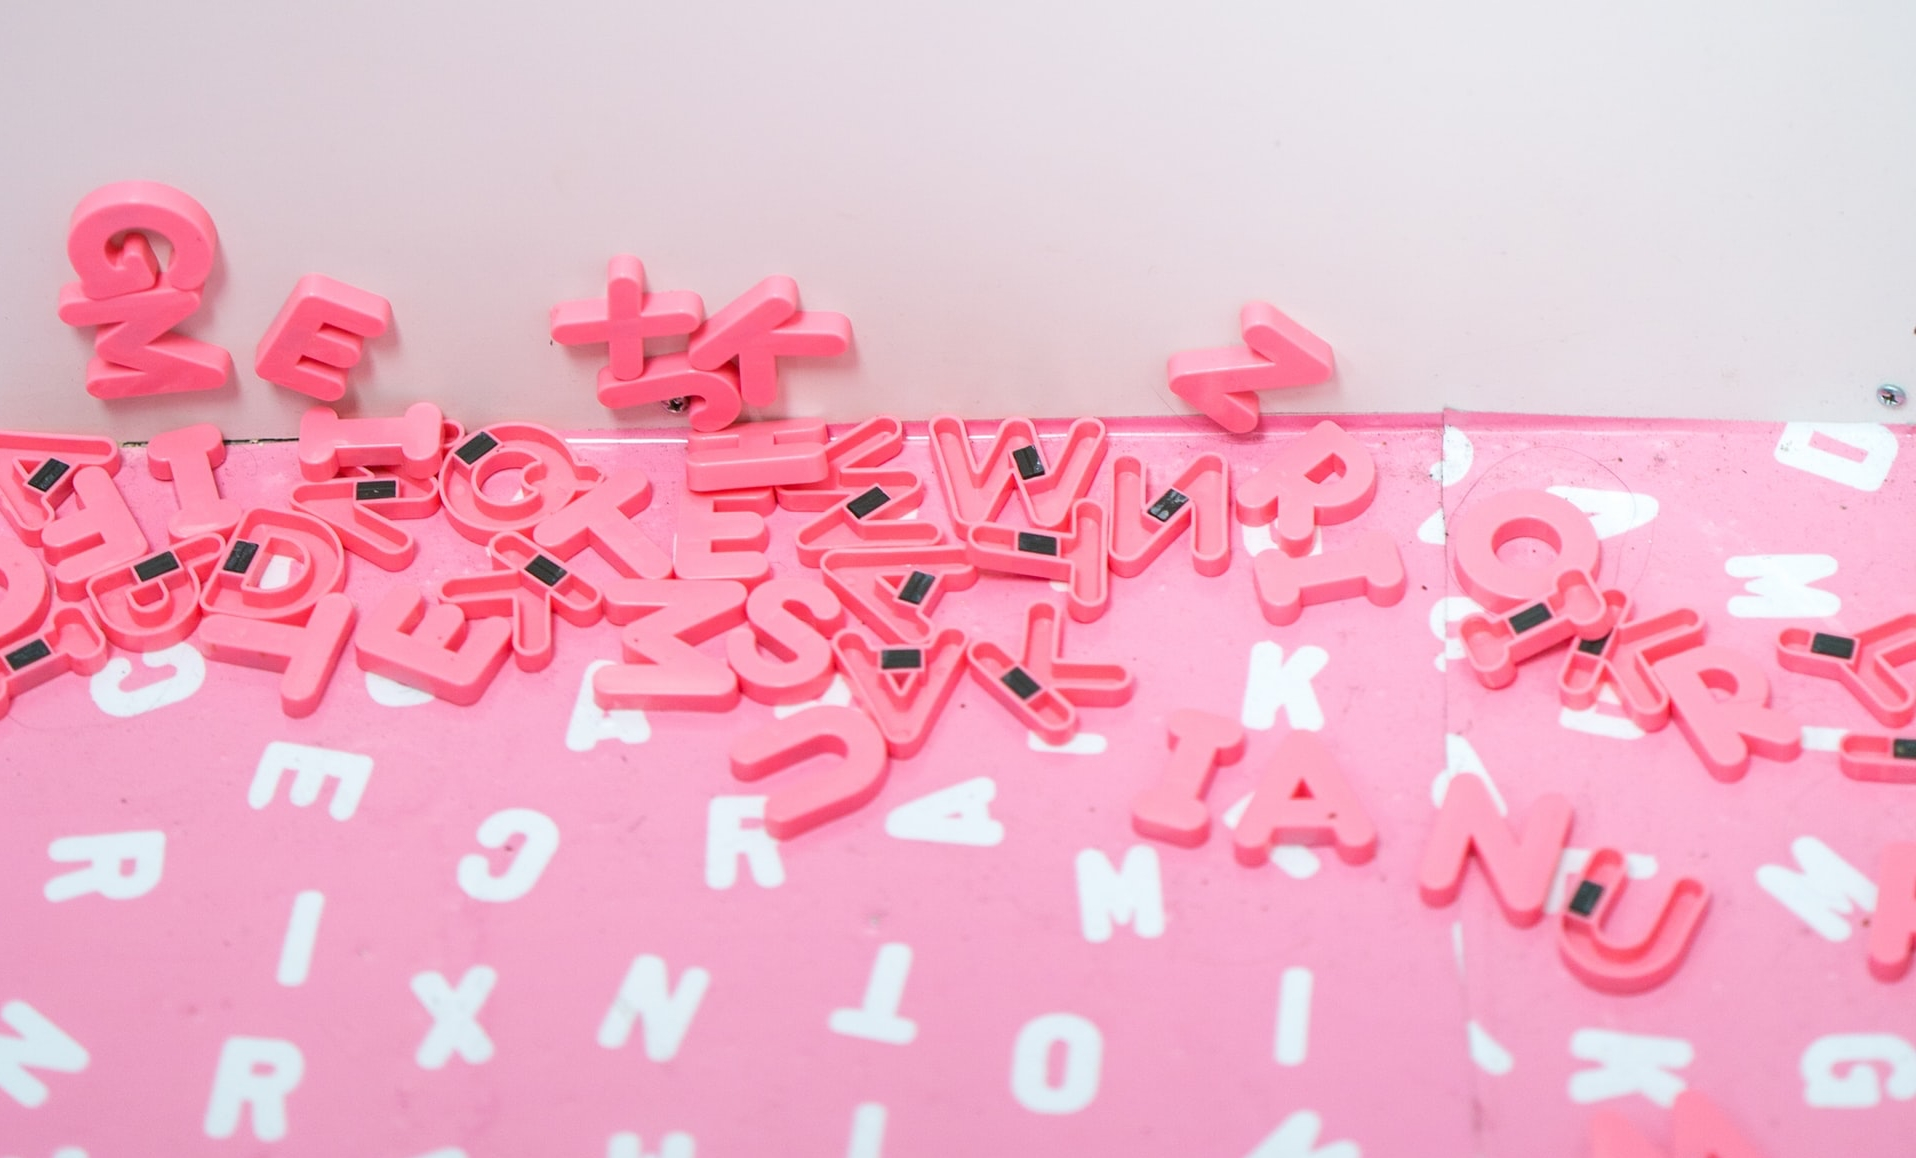

*Credits*: <span>Photo by <a href="https://unsplash.com/@ninjason?utm_source=unsplash&amp;utm_medium=referral&amp;utm_content=creditCopyText">Jason Leung</a> on <a href="https://unsplash.com/s/photos/language?utm_source=unsplash&amp;utm_medium=referral&amp;utm_content=creditCopyText">Unsplash</a></span>

The place of language in our lives is hard to overestimate. It helps us to convey meaning and not rarely serves as a means of persuasion.

Have you ever noticed that words may be a good indicator of the cost? "Exclusive", "brand-new", "luxurious" and similar terms signal that the service or the product described will be rather expensive. 

Well, if it's in fact so, can we create a program that would predict prices by product names? Sure, we can!

Today we'll use NLP to understand whether there are particular wordings that indicate high end prices for Airbnb places in New Yourk City.


[Preprocessing](#prep)

[Most frequent words](#freq_words)

[Most frequent bigrams](#freq_bigrams)

[Most frequent trigrams](#freq_trigrams)

[But what about a price?](#price)

[Most frequent wordings for expensive places](#top_costly_words)

[ML model](#model)

[Interpreting ML predictions](#interpret)

[Wrapping up](#wrapping_up)


First, let's load the data and take a quick look at it.

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
import seaborn as sns

from PIL import Image
from wordcloud import WordCloud

import spacy
import nltk
from nltk.util import ngrams

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, f1_score, classification_report, mean_absolute_error, r2_score
from imblearn.over_sampling import RandomOverSampler, SMOTE

import lime
from lime import lime_text
from lime.lime_text import LimeTextExplainer
from sklearn.pipeline import make_pipeline

In [ ]:
data = pd.read_csv('/kaggle/input/new-york-city-airbnb-open-data/AB_NYC_2019.csv')
data.shape

In [ ]:
data.head()

Let's look at the columns of our data.

* id - Listing ID
* name - Listing Title
* host_id - ID of Host
* host_name - Name of Host
* neighbourhood_group - Borough that contains listing
* neighbourhood - Name of neighbourhood that listing is in
* latitude - latitude of listing
* longitude - longitude of listing
* room_type - Type of public space that is being offered
* price - price per night, USD
* minimum_nights - minimum number of nights required to book listing
* number_of_reviews - total number of reviews that listing has accumulated
* last_review - date in which listing was last rented
* reviews_per_month - total number of reviews divided by the number of months the listing is active
* calculated_host_listings_count - amount of listing per host**
* availability_365 - number of days per year the listing is active

As we are interested in textual descriptions of appartments, we need to preprocess data in `name` column for further use.

## <a id='prep'></a> <font color='orange'> Preprocessing
### <font color='orange'> 1. Check if there are missing values. If so, swap it with an empty string.


In [ ]:
# Looks like there are 16 objects with no description.
data[data['name'].isnull()]

In [ ]:
# Fill NaN with an empty string and check missing values again
data['name'].fillna('', inplace=True)
data['name'].isnull().sum()

### <font color='orange'> 2. Remove punctuation, digits and special characters.

In [ ]:
def remove_punct(line):
    return re.sub('[^A-Za-z]+', ' ', line).lower()

data['clean_name'] = data['name'].apply(remove_punct)

In [ ]:
# Let's compare raw and cleaned texts.
data[['name', 'clean_name']]

### <font color='orange'> 3. Get rid of stopwords, i.e. words conveying no meaning such as articles, conjunctions, etc. 

In [ ]:
nlp = spacy.load("en")
stopwords = nlp.Defaults.stop_words

In [ ]:
def tokenize_no_stopwords(line):
    tokens = nltk.tokenize.word_tokenize(line)
    tokens_no_stop = [w for w in tokens if w not in stopwords]
    return " ".join(tokens_no_stop)

In [ ]:
data['final_name'] = data['clean_name'].apply(tokenize_no_stopwords)

In [ ]:
# Well, looks about right
data[['clean_name', 'final_name']]

## <a id='freq_words'></a> <font color='purple'> Most frequent words to describe NYC appartments.
    
Let's take a look at what words are usually used by owners to describe their places.

In [ ]:
# first, we need to concatenate all descriptions in one string
text = ""
for i in data['final_name']:
    text += " " + i
    
# next, we tokenize it into separate words
tokenized_text = nltk.tokenize.word_tokenize(text)

# finally, create a frequency dictionary with the help of nltk
freq_dict = nltk.FreqDist(w for w in tokenized_text)

In [ ]:
def plot_most_common(dict_data ,title):
    df = pd.DataFrame(dict_data)
    df.columns = ['word', 'count']
    plt.figure(figsize=(8, 8))
    sns.set(style="darkgrid")
    sns.barplot(x="count", y="word", data=df, palette='twilight')
    plt.title(title)
    plt.show()
    
plot_most_common(freq_dict.most_common(20), 'Top 20 frequent words for NYC Airbnb titles')

## <a id='freq_bigrams'></a> <font color='purple'> Most frequent bigrams to describe NYC appartments.

Most of top 20 words obtained in the previous section aren't really specific for New York. Now we'll find top bigrams, i.e. the sequences of two neighbouring words, used in Airbnb titles for NYC flats.

In [ ]:
freq_dict_bigrams = nltk.FreqDist(nltk.bigrams(w for w in tokenized_text))
plot_most_common(freq_dict_bigrams.most_common(20), 'Top 20 frequent bigrams for NYC Airbnb titles')

Well, now the plot looks much more specific for the city. We can see such bigrams as:
* East and West Village
* Central Park
* New York
* Upper East

## <a id='freq_trigrams'></a> <font color='purple'> Most frequent trigrams to describe NYC appartments.

As long as we are here and looking at n-grams used in Airbnb titles, let's create a plot for top trigrams.
    
We find a very interesting trigram indeed - hell's kitchen - the name of a popular NYC area.

In [ ]:
freq_dict_trigrams = nltk.FreqDist(nltk.trigrams(w for w in tokenized_text))
plot_most_common(freq_dict_trigrams.most_common(20), 'Top 20 frequent trigrams for NYC Airbnb titles')

## <a id='price'></a> <font color='green'> But what about the price?

Can we predict, at least approximately, how much a place will cost us just by looking at its Airbnb title?

Well, let's find out.

In [ ]:
# First, we are going to take a look at the price distribution
plt.figure(figsize=(8, 8))
sns.distplot(data['price'])
plt.show()

In [ ]:
data['price'].describe()

Most apparntments can be rented with approximately \$200. However, the right tail is quite long meaning there are places with much higher prices.

## <a id='top_costly_words'></a> <font color='scarlett'> Most frequent wordings for expensive places

Let's explore the titles of the appartments that cost more than 1k for a night.

In [ ]:
costly = data[data['price']>1000]
costly.shape

In [ ]:
# first, we need to concatenate all descriptions in one string
costly_text = ""
for i in costly['final_name']:
    costly_text += " " + i
    
# next, we tokenize it into separate words
tokenized_costly_text = nltk.tokenize.word_tokenize(costly_text)

# finally, create a frequency dictionary with the help of nltk
freq_dict_costly = nltk.FreqDist(w for w in tokenized_costly_text)

In [ ]:
plot_most_common(freq_dict_costly.most_common(20), "Top 20 words in pricy apartments' titles")

In [ ]:
freq_dict_bigrams_costly = nltk.FreqDist(nltk.bigrams(w for w in tokenized_costly_text))
plot_most_common(freq_dict_bigrams_costly.most_common(20), "Top 20 bigrams in pricy apartments' titles")

In [ ]:
freq_dict_trigrams_costly = nltk.FreqDist(nltk.trigrams(w for w in tokenized_costly_text))
plot_most_common(freq_dict_trigrams_costly.most_common(20), "Top 20 trigrams in pricy apartments' titles")

By looking at the plots above, it's easy to identify some kind of pattern. We encounter some terms that weren't present in the list of frequently used words when we were looking at all the data.

Titles for appartments with high end prices uses such words as:
* lux, luxury
* Manhattan
* Townhouse
* Chelsea Gallery
* Super Bowl
* park views

Seems right to me. You *do* expect an appartment with a park view or near Chelsea Gallery to be a bit more expensive than a median price tag. The same for the term "luxury".

## <a id='model'></a> <font color='navy'> ML model

Now let's create an ML model that will try to answer the question "Is the price of an Airbnb place in New York higher than 500 a night?" by utilizing only the title describing an appartment.

In [ ]:
def new_target(line):
    if line > 500:
        return 1
    else:
        return 0
        
data['target'] = data['price'].apply(new_target)
data['target'].value_counts()

In [ ]:
train, test = train_test_split(data, test_size=0.2, random_state=315, stratify=data['target'])

X_train, y_train = train['final_name'], train['target']
X_test, y_test = test['final_name'], test['target']

X_train.shape, y_train.shape, X_test.shape, y_test.shape

In [ ]:
vect = TfidfVectorizer()
X_train = vect.fit_transform(X_train)
X_test = vect.transform(X_test)

Since the classes are not balanced (there are much more objects of class 0), we'll use resampling.

More details on dealing with imabalanced data can be found in [this notebook](https://www.kaggle.com/amidala/handling-imbalanced-data-with-resampling)


In [ ]:
ros = RandomOverSampler(sampling_strategy='minority', random_state=1)

X_train_ros, y_train_ros = ros.fit_sample(X_train, y_train)
np.bincount(y_train_ros)

In [ ]:
lr = LGBMClassifier(random_state=315)
lr.fit(X_train_ros, y_train_ros)
preds = lr.predict(X_test)

In [ ]:
print(classification_report(y_test, preds))

In [ ]:
def draw_cm(y_test, y_pred):
  cm = confusion_matrix(y_test, y_pred)
  cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
  df_cm = pd.DataFrame(cm_norm)
  plt.figure(figsize = (6,4))
  sns.heatmap(df_cm, annot=True, cmap="Blues")
  plt.xlabel("Predicted class")
  plt.ylabel("True class")
  print("Accuracy: {0:.3f}".format(accuracy_score(y_test, y_pred)))
  print("Recall: {0:.3f}".format(recall_score(y_test, y_pred)))
  plt.show()

In [ ]:
draw_cm(y_test, preds)

Alright, the scores aren't perfect but taking into account that the predicting model is built solely on textual descriptions of an appatment, it seems like the words in Airbnb titles actually **do** matter!


## <a id='interpret'></a> <font color='purple'> Interpreting ML predictions

Let's create human-friendly interpretations for our prediction using [LIME](https://github.com/marcotcr/lime).

More details on how to interpret ML models' predictions is in [this kernel](https://www.kaggle.com/amidala/explain-your-ml-model-no-more-black-boxes)

In [ ]:
# create a pipeline and a LIME's explainer object
c = make_pipeline(vect, lr)
class_names=['cheaper', 'expensive']
explainer = LimeTextExplainer(class_names=class_names)

# use them to explain an individual prediction

ind = 48050
exp = explainer.explain_instance(test.loc[ind]['final_name'], c.predict_proba, labels=[1])
exp.show_in_notebook(text=True)

ind_pred = c.predict_proba([test.loc[ind]['final_name']])

print("True class: {}".format(class_names[test.loc[ind]['target']]))
print("Predicted class: {}".format(class_names[np.argmax(ind_pred)]))

In [ ]:
ind = 19427
exp = explainer.explain_instance(test.loc[ind]['final_name'], c.predict_proba, labels=[1])
exp.show_in_notebook(text=True)

ind_pred = c.predict_proba([test.loc[ind]['final_name']])

print("True class: {}".format(class_names[test.loc[ind]['target']]))
print("Predicted class: {}".format(class_names[np.argmax(ind_pred)]))

The interpretation shows us that such terms as `bluebird`, `luxury`, `riverview` do appear in the titles of more expensive places. The word `group` is also frequently encountered in descriptions of a high price apartments as this usually indicates that the place is large and may be a better suit for several people.

## <a id='wrapping_up'></a> <font color='green'> Wrapping up 

In this notebook we have identified interesting patterns. For instance:
* It's possible to guess the price range of an Airbnb apartment by simply looking at its title.
* More expensive places use such words as `luxury`, `elegant`, `views`, `groups`, etc.
* Flats which titles indicate the vicinity of city attractions also tend to cost more.
    
Looks like it's important what to write in the title of your Airbnb place after all!
    
Hope you find this quick analysis helpful and funny. If so, upvote :)